<a href="https://colab.research.google.com/github/briskicedteaa/rdkit-cheminformatics-notebooks-/blob/main/Visualizing_Molecules.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!pip install rdkit
from rdkit import Chem
import pandas as pd
from rdkit.Chem.Draw import MolsToGridImage

In [2]:
df = pd.read_csv('/content/File.csv', sep =';' )
df = df.drop(columns=df.columns.difference(['Target ChEMBL ID', 'Smiles']))
df = df.dropna()
df

,Smiles,Target ChEMBL ID
0,CN1CC[C@@]2(C)c3cc(OC(=O)NCCCCCCCCCN4CCOCC4)cc...,CHEMBL220
1,Cc1ccc(C(=O)/C(=N/O)SCC[N+](C)(C)C)cc1.[Cl-],CHEMBL220
2,NC(=O)c1cc[n+](C/C=C/C[n+]2ccc(/C=N/O)cc2)cc1....,CHEMBL220
3,O/N=C/c1cc[n+](CCC[n+]2ccccc2)cc1.[Br-].[Br-],CHEMBL220
4,O/N=C/c1cc[n+](CCC[n+]2ccc3ccccc3c2)cc1.[Br-]....,CHEMBL220
...,...,...
20127,CC1=CC(=O)[C@@](C)(O)C(=O)/C1=C\Nc1ccc(Cc2cccc...,CHEMBL220
20128,COc1cc2c(cc1OCCCCCC1CCSS1)C(=O)C(CC1CCN(Cc3ccc...,CHEMBL220
20129,C#CCCCOc1c(CN2CCc3ccccc3C2)cc(-c2cc(=O)c3ccccc...,CHEMBL220
20130,O=C(CCC1CCN(CC2CCCCC2)CC1)c1ccc(O)cc1,CHEMBL220


In [11]:
for index, row in df.iterrows():
  target_ID = row['Target ChEMBL ID']
  smiles_string = row['Smiles']
  mol = Chem.MolFromSmiles(smiles_string)

valid_mask = [Chem.MolFromSmiles(s) is not None for s in df['Smiles']]

df = df[valid_mask]

df.to_csv('File.csv', index=False)

display(df)

,Smiles,Target ChEMBL ID
0,CN1CC[C@@]2(C)c3cc(OC(=O)NCCCCCCCCCN4CCOCC4)cc...,CHEMBL220
1,Cc1ccc(C(=O)/C(=N/O)SCC[N+](C)(C)C)cc1.[Cl-],CHEMBL220
2,NC(=O)c1cc[n+](C/C=C/C[n+]2ccc(/C=N/O)cc2)cc1....,CHEMBL220
3,O/N=C/c1cc[n+](CCC[n+]2ccccc2)cc1.[Br-].[Br-],CHEMBL220
4,O/N=C/c1cc[n+](CCC[n+]2ccc3ccccc3c2)cc1.[Br-]....,CHEMBL220
...,...,...
20127,CC1=CC(=O)[C@@](C)(O)C(=O)/C1=C\Nc1ccc(Cc2cccc...,CHEMBL220
20128,COc1cc2c(cc1OCCCCCC1CCSS1)C(=O)C(CC1CCN(Cc3ccc...,CHEMBL220
20129,C#CCCCOc1c(CN2CCc3ccccc3C2)cc(-c2cc(=O)c3ccccc...,CHEMBL220
20130,O=C(CCC1CCN(CC2CCCCC2)CC1)c1ccc(O)cc1,CHEMBL220


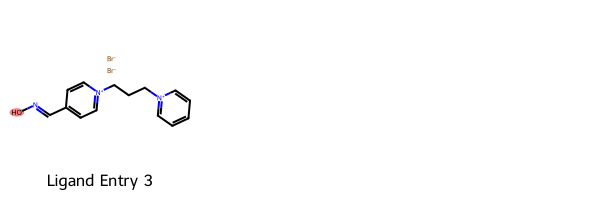

In [12]:
mols = [Chem.MolFromSmiles(s) for s in ['O/N=C/c1cc[n+](CCC[n+]2ccccc2)cc1.[Br-].[Br-]']]
legend = ['Ligand Entry 3']
MolsToGridImage(mols, legends=legend, highlightAtomLists=[[0]], subImgSize=(200, 200))

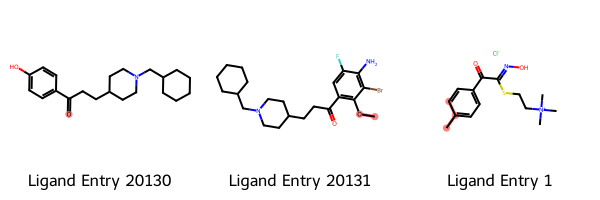

In [13]:
mols = [Chem.MolFromSmiles(s) for s in ['O=C(CCC1CCN(CC2CCCCC2)CC1)c1ccc(O)cc1', 'COc1c(C(=O)CCC2CCN(CC3CCCCC3)CC2)cc(F)c(N)c1Br', 'Cc1ccc(C(=O)/C(=N/O)SCC[N+](C)(C)C)cc1.[Cl-]']]
legends = ['Ligand Entry 20130', 'Ligand Entry 20131', 'Ligand Entry 1']
MolsToGridImage(mols, legends=legends, highlightAtomLists=[[0], [0,1], [0,1,2]], subImgSize=(200, 200))

In [19]:
from rdkit.Chem.Draw import IPythonConsole

m = Chem.MolFromSmiles('O/N=C/c1cc[n+](CCC[n+]2ccccc2)cc1.[Br-].[Br-]')
substructure = Chem.MolFromSmarts('CC(=O)NC1=CC=C(C=C1)O')
print(m.GetSubstructMatches(substructure))

()
